# Random Variables, Expectation, and Variance

## Learning Objectives

By the end of this notebook you will be able to:

1. Define a **random variable** as a function from outcomes to numbers.
2. Compute and plot the **probability mass function** (PMF) and **cumulative distribution function** (CDF) for discrete random variables.
3. Compute the **expected value** $E[X]$ and interpret it as a weighted average.
4. Compute the **variance** $\text{Var}(X)$ and **standard deviation** $\sigma_X$.
5. Apply the **linearity of expectation** and variance scaling rules.
6. Recognise these concepts as the bridge to **named distributions** (Module 02).

## Prerequisites

- [01_sample_spaces.ipynb](01_sample_spaces.ipynb) — sample spaces, events, axioms
- [04_law_of_total_probability.ipynb](04_law_of_total_probability.ipynb) — total expectation (previewed there)

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()

---

## 1. From Events to Numbers: What is a Random Variable?

So far we've worked with **events** — subsets of the sample space like "roll an even number" or "draw a heart". But in statistics we almost always need **numbers**: the sum of two dice, the number of heads in 10 flips, the waiting time until the next bus.

A random variable formalises this idea.

> **Definition 5.1 (Random variable).** A *random variable* $X$ is a function that assigns a real number to each outcome in $\Omega$:
>
> $$X : \Omega \to \mathbb{R}$$

We use capital letters ($X$, $Y$, $Z$) for random variables and lowercase ($x$, $y$, $z$) for specific values they can take.

### Example: sum of two dice

The sample space is $\Omega = \{(i,j) : i,j \in \{1,\dots,6\}\}$ with 36 outcomes. Define $X((i,j)) = i + j$. Then $X$ is a random variable that takes values in $\{2, 3, \dots, 12\}$.

- The outcome $(3, 4)$ maps to $X = 7$.
- The event "$X = 7$" corresponds to the set $\{(1,6),(2,5),(3,4),(4,3),(5,2),(6,1)\}$.

### Example: number of heads

Flip a coin 3 times. $\Omega = \{HHH, HHT, HTH, \dots, TTT\}$ (8 outcomes). Let $X$ = number of heads. Then $X$ takes values 0, 1, 2, 3.

### Discrete vs. continuous

A random variable is **discrete** if it takes finitely many (or countably many) values: die rolls, counts, categories.

A random variable is **continuous** if it can take any value in an interval: heights, temperatures, waiting times.

In this notebook we focus on **discrete** random variables. Continuous RVs appear in Module 02.

In [ ]:
# Example: X = sum of two dice
omega = [(i, j) for i in range(1, 7) for j in range(1, 7)]

# The random variable X maps each outcome to a number
X_values = [i + j for (i, j) in omega]

# Which outcomes map to X = 7?
x7 = [(i, j) for (i, j) in omega if i + j == 7]
print(f"Outcomes where X = 7: {x7}")
print(f"P(X = 7) = {len(x7)}/36 = {len(x7) / 36:.4f}")

Outcomes where X = 7: [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)]
P(X = 7) = 6/36 = 0.1667


---

## 2. The Probability Mass Function (PMF)

A discrete random variable is fully described by its **PMF** — the function that tells us the probability of each value.

> **Definition 5.2 (PMF).** The *probability mass function* of a discrete random variable $X$ is
>
> $$p_X(x) = P(X = x) \quad \text{for each possible value } x$$

The PMF must satisfy:
1. $p_X(x) \geq 0$ for all $x$ (non-negativity)
2. $\sum_x p_X(x) = 1$ (normalisation)

These follow directly from the Kolmogorov axioms (notebook 01).

### Example: PMF of the sum of two dice

In [3]:
# From scratch: compute the PMF of X = sum of two dice
def pmf_two_dice():
    """Return {x: P(X=x)} for X = sum of two fair dice."""
    counts = {}
    for i in range(1, 7):
        for j in range(1, 7):
            s = i + j
            counts[s] = counts.get(s, 0) + 1
    return {x: c / 36 for x, c in sorted(counts.items())}


pmf = pmf_two_dice()
print("x   P(X=x)")
print("-" * 15)
for x, p in pmf.items():
    print(f"{x:2d}   {p:.4f}")
print(f"\nSum = {sum(pmf.values()):.4f}  (must be 1.0)")

x   P(X=x)
---------------
 2   0.0278
 3   0.0556
 4   0.0833
 5   0.1111
 6   0.1389
 7   0.1667
 8   0.1389
 9   0.1111
10   0.0833
11   0.0556
12   0.0278

Sum = 1.0000  (must be 1.0)


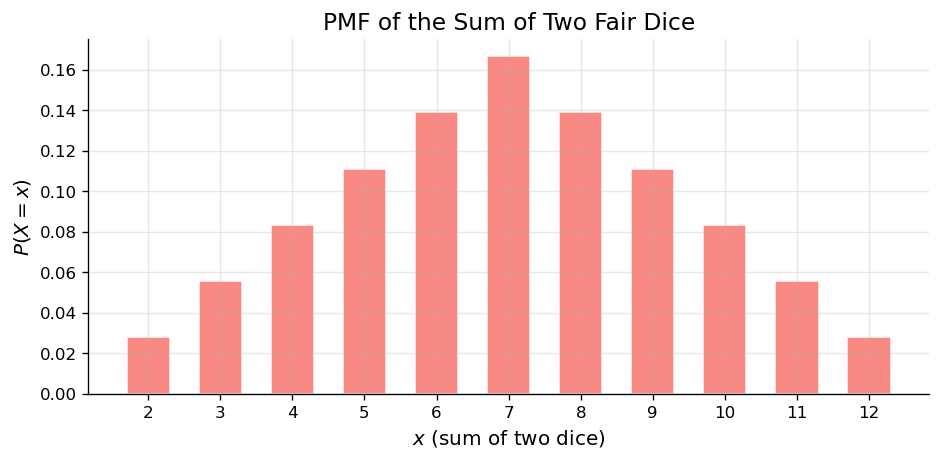

In [4]:
# Plot the PMF
xs = list(pmf.keys())
ps = list(pmf.values())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xs, ps, width=0.6, edgecolor="white", alpha=0.85)
ax.set_xlabel("$x$ (sum of two dice)")
ax.set_ylabel("$P(X = x)$")
ax.set_title("PMF of the Sum of Two Fair Dice")
ax.set_xticks(xs)
plt.tight_layout()
plt.show()

The triangular shape reflects the counting argument from notebook 02: more combinations produce sums near 7 than sums near 2 or 12.

---

## 3. The Cumulative Distribution Function (CDF)

The CDF answers a different question: not "what is the probability of exactly $x$?" but "what is the probability of **at most** $x$?"

> **Definition 5.3 (CDF).** The *cumulative distribution function* of $X$ is
>
> $$F_X(x) = P(X \leq x) = \sum_{t \leq x} p_X(t)$$

Key properties:
- $F_X$ is **non-decreasing**: if $a < b$ then $F_X(a) \leq F_X(b)$.
- $\lim_{x \to -\infty} F_X(x) = 0$ and $\lim_{x \to +\infty} F_X(x) = 1$.
- For discrete RVs, $F_X$ is a **step function** — it jumps at each value with positive probability.
- We can recover the PMF from the CDF: $p_X(x) = F_X(x) - F_X(x^-)$ (the jump size at $x$).
- Range probabilities: $P(a < X \leq b) = F_X(b) - F_X(a)$.

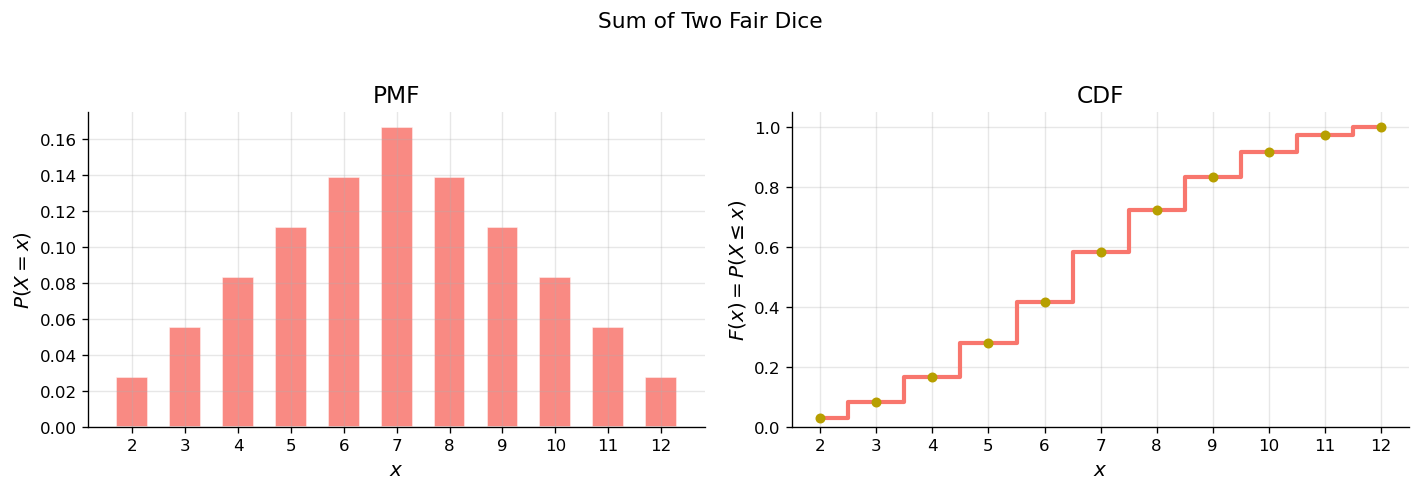

P(X ≤ 7) = F(7) = 0.5833
P(5 < X ≤ 9) = F(9) - F(5) = 0.5556


In [5]:
# From scratch: compute the CDF from the PMF
def cdf_from_pmf(pmf_dict):
    """Given {x: P(X=x)}, return {x: P(X<=x)}."""
    cdf = {}
    cumulative = 0.0
    for x in sorted(pmf_dict):
        cumulative += pmf_dict[x]
        cdf[x] = cumulative
    return cdf


cdf = cdf_from_pmf(pmf)

# Plot PMF and CDF side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PMF
axes[0].bar(xs, ps, width=0.6, edgecolor="white", alpha=0.85)
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$P(X = x)$")
axes[0].set_title("PMF")
axes[0].set_xticks(xs)

# CDF as a step function
cdf_xs = sorted(cdf.keys())
cdf_ys = [cdf[x] for x in cdf_xs]
axes[1].step(cdf_xs, cdf_ys, where="mid", linewidth=2.5)
axes[1].plot(cdf_xs, cdf_ys, "o", markersize=5)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$F(x) = P(X \leq x)$")
axes[1].set_title("CDF")
axes[1].set_xticks(xs)
axes[1].set_ylim(0, 1.05)

plt.suptitle("Sum of Two Fair Dice", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Example: P(X ≤ 7)
print(f"P(X ≤ 7) = F(7) = {cdf[7]:.4f}")
print(f"P(5 < X ≤ 9) = F(9) - F(5) = {cdf[9] - cdf[5]:.4f}")

---

## 4. Expected Value (Mean)

The **expected value** is the most important single-number summary of a random variable. It answers: "If I repeated this experiment many times, what would the average outcome be?"

> **Definition 5.4 (Expected value).** For a discrete random variable $X$ with PMF $p_X$:
>
> $$E[X] = \sum_{x} x \cdot p_X(x)$$

This is a **weighted average** of the possible values, weighted by their probabilities. It is *not* the most likely value — it's the long-run average if we repeat the experiment infinitely many times (by the law of large numbers from notebook 01).

### Example: fair die

$$E[X] = 1 \cdot \frac{1}{6} + 2 \cdot \frac{1}{6} + \cdots + 6 \cdot \frac{1}{6} = \frac{21}{6} = 3.5$$

Note: $E[X] = 3.5$ is not a possible outcome! The expected value doesn't have to be a value the RV can take.

### Example: sum of two dice

$$E[X] = \sum_{x=2}^{12} x \cdot P(X = x)$$

In [ ]:
# From scratch: expected value
def expected_value(pmf_dict):
    """E[X] = sum of x * P(X=x)."""
    return sum(x * p for x, p in pmf_dict.items())


# Fair die
pmf_die = {x: 1 / 6 for x in range(1, 7)}
print(f"E[fair die] = {expected_value(pmf_die):.4f}")

# Sum of two dice
print(f"E[sum of two dice] = {expected_value(pmf):.4f}")

# Verify with simulation
rng = np.random.default_rng(42)
rolls = rng.integers(1, 7, size=(100_000, 2))
sums = rolls.sum(axis=1)
print(f"Simulated mean (n=100,000): {sums.mean():.4f}")

E[fair die] = 3.5000
E[sum of two dice] = 7.0000
Simulated mean (n=100,000): 7.0055


The animation below shows the expected value as the **balance point** of the PMF — if you placed the probability bars on a see-saw, it would balance at $E[X]$.

In [7]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

Manim Community v0.18.1

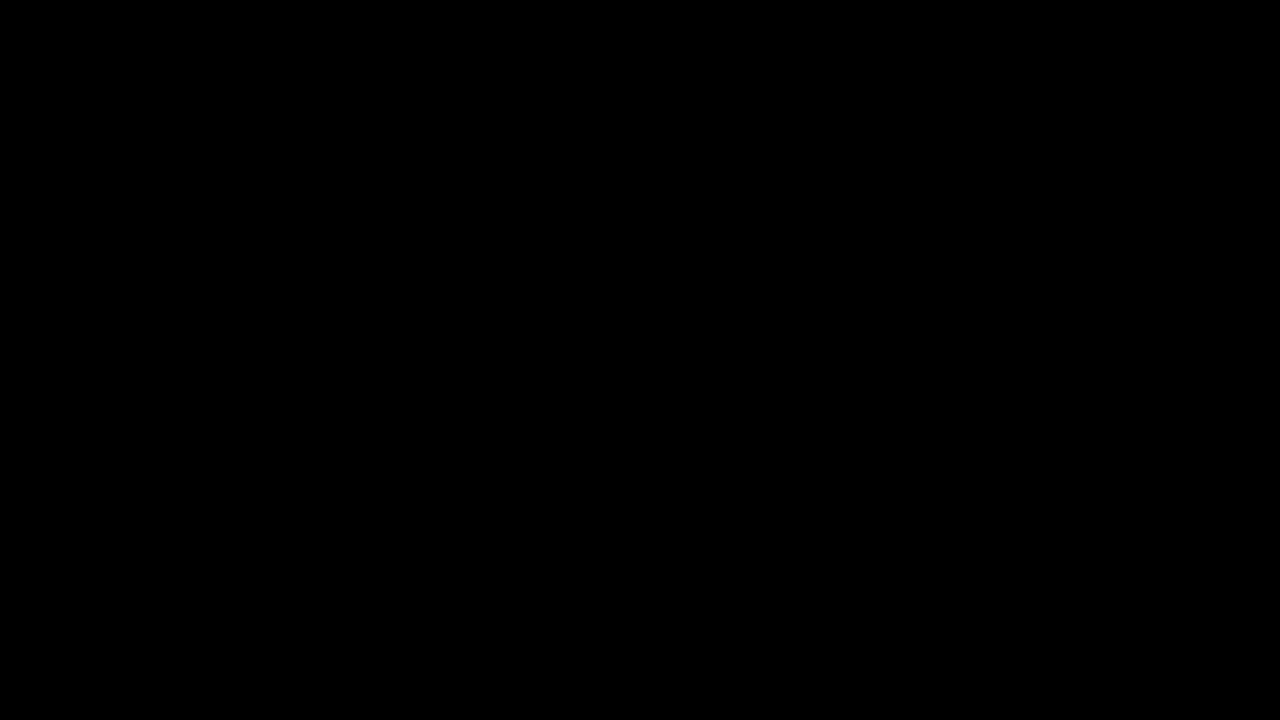

In [ ]:
%%manim -qm -v WARNING ExpectedValueBalance


class ExpectedValueBalance(Scene):
    """Show E[X] as the balance point of the PMF."""

    def construct(self):
        title = Text("Expected Value = Balance Point of the PMF", font_size=28).to_edge(
            UP
        )
        self.play(Write(title))

        # PMF of a fair die
        faces = list(range(1, 7))
        probs = [1 / 6] * 6
        ex = 3.5

        # Draw axes
        axes = Axes(
            x_range=[0, 7, 1],
            y_range=[0, 0.25, 0.05],
            x_length=8,
            y_length=3.5,
            axis_config={"include_numbers": True, "font_size": 20},
        ).shift(DOWN * 0.5)
        x_lbl = axes.get_x_axis_label(
            Text("x", font_size=20), edge=DOWN, direction=DOWN
        )
        y_lbl = axes.get_y_axis_label(
            Text("P(X=x)", font_size=18), edge=LEFT, direction=LEFT
        )
        self.play(Create(axes), Write(x_lbl), Write(y_lbl), run_time=0.8)

        # Draw bars
        bars = VGroup()
        for x, p in zip(faces, probs):
            bar = Rectangle(
                width=0.5,
                height=p * (3.5 / 0.25),
                fill_color=C.PERIWINKLE,
                fill_opacity=0.7,
                stroke_color=WHITE,
                stroke_width=1,
            ).move_to(axes.c2p(x, p / 2))
            bars.add(bar)
        self.play(FadeIn(bars), run_time=0.8)

        # Draw the balance point (triangle under the axis)
        pivot_point = axes.c2p(ex, 0)
        triangle = (
            Triangle(color=C.SALMON, fill_color=C.SALMON, fill_opacity=0.9)
            .scale(0.25)
            .move_to(pivot_point + DOWN * 0.35)
        )

        ex_label = math_text(r"E[X] = 3.5", font_size=26, color=C.SALMON).next_to(
            triangle, DOWN, buff=0.15
        )

        # Dashed vertical line at E[X]
        dashed = DashedLine(
            axes.c2p(ex, 0),
            axes.c2p(ex, 1 / 6),
            color=C.SALMON,
            stroke_width=2,
            dash_length=0.08,
        )

        self.play(FadeIn(triangle), Write(ex_label), Create(dashed), run_time=1)
        self.wait(2)

For a fair die, the PMF is flat (all bars equal height), so the balance point is exactly in the middle at 3.5. For a skewed distribution, the balance point shifts toward the heavier side.

### Expectation of a function of $X$

An important generalisation: if $g$ is any function, then

$$E[g(X)] = \sum_x g(x) \cdot p_X(x)$$

This is called the **law of the unconscious statistician** (LOTUS). We don't need the PMF of $g(X)$ — we can compute the expectation directly from the PMF of $X$. We'll use this to define variance.

---

## 5. Properties of Expectation

Expectation has remarkably clean algebraic properties:

> **Theorem 5.5 (Linearity of expectation).** For any random variables $X$, $Y$ and constants $a$, $b$:
>
> $$E[aX + b] = a \cdot E[X] + b$$
>
> $$E[X + Y] = E[X] + E[Y]$$
>
> The second property holds **even if $X$ and $Y$ are not independent**.

This is extremely powerful. For example, the expected sum of two dice is:

$$E[X_1 + X_2] = E[X_1] + E[X_2] = 3.5 + 3.5 = 7$$

No need to compute the PMF of the sum — linearity gives the answer directly.

In [ ]:
# Verify linearity with simulation
rng = np.random.default_rng(42)
n = 100_000

X = rng.integers(1, 7, size=n)  # die 1
Y = rng.integers(1, 7, size=n)  # die 2

print(f"E[X]     = {X.mean():.4f}  (theory: 3.5)")
print(f"E[Y]     = {Y.mean():.4f}  (theory: 3.5)")
print(f"E[X+Y]   = {(X + Y).mean():.4f}  (theory: 7.0)")
print(f"E[X]+E[Y]= {X.mean() + Y.mean():.4f}")

# Linearity: E[3X + 2] = 3*E[X] + 2
print(f"\nE[3X+2]  = {(3 * X + 2).mean():.4f}  (theory: 3×3.5+2 = {3 * 3.5 + 2})")

E[X]     = 3.4998  (theory: 3.5)
E[Y]     = 3.5057  (theory: 3.5)
E[X+Y]   = 7.0055  (theory: 7.0)
E[X]+E[Y]= 7.0055

E[3X+2]  = 12.4995  (theory: 3×3.5+2 = 12.5)


---

## 6. Variance and Standard Deviation

The expected value tells us the *centre* of a distribution. But two distributions can have the same mean and look very different — one might be tightly concentrated, the other spread wide. **Variance** measures this spread.

> **Definition 5.6 (Variance).** The *variance* of $X$ is the expected squared deviation from the mean:
>
> $$\text{Var}(X) = E[(X - E[X])^2] = \sum_x (x - \mu)^2 \cdot p_X(x)$$
>
> where $\mu = E[X]$.

> **Definition 5.7 (Standard deviation).** $\sigma_X = \sqrt{\text{Var}(X)}$ — same units as $X$.

### Computational shortcut

Expanding the square gives a useful alternative formula:

$$\text{Var}(X) = E[X^2] - (E[X])^2$$

"The mean of the square minus the square of the mean."

### Properties of variance

| Property          | Formula                                             | Note                         |
|-------------------|-----------------------------------------------------|------------------------------|
| Non-negative      | $\text{Var}(X) \geq 0$                              | Zero only if $X$ is constant |
| Adding a constant | $\text{Var}(X + b) = \text{Var}(X)$                 | Shifts don't change spread   |
| Scaling           | $\text{Var}(aX) = a^2 \text{Var}(X)$                | Note: $a^2$, not $a$         |
| Combined          | $\text{Var}(aX + b) = a^2 \text{Var}(X)$            |                              |
| Independent sum   | $\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y)$ | Only if $X \perp Y$          |

In [10]:
# From scratch: variance two ways
def variance(pmf_dict):
    """Var(X) = E[(X - mu)^2]."""
    mu = expected_value(pmf_dict)
    return sum((x - mu) ** 2 * p for x, p in pmf_dict.items())


def variance_shortcut(pmf_dict):
    """Var(X) = E[X^2] - (E[X])^2."""
    mu = expected_value(pmf_dict)
    e_x2 = sum(x**2 * p for x, p in pmf_dict.items())
    return e_x2 - mu**2


# Fair die
var_die = variance(pmf_die)
var_die_shortcut = variance_shortcut(pmf_die)
print(f"Var(fair die) = {var_die:.4f}")
print(f"Shortcut:       {var_die_shortcut:.4f}")
print(f"SD(fair die)  = {var_die**0.5:.4f}")

# Sum of two dice
var_sum = variance(pmf)
print(f"\nVar(sum of two dice) = {var_sum:.4f}")
print(f"SD = {var_sum**0.5:.4f}")

# Verify: Var(X1 + X2) = Var(X1) + Var(X2) for independent dice
print(f"Var(X1) + Var(X2) = {2 * var_die:.4f}  (should match {var_sum:.4f})")

Var(fair die) = 2.9167
Shortcut:       2.9167
SD(fair die)  = 1.7078

Var(sum of two dice) = 5.8333
SD = 2.4152
Var(X1) + Var(X2) = 5.8333  (should match 5.8333)


In [11]:
# Stage 3: PROFESSIONAL — NumPy
die_rolls = rng.integers(1, 7, size=100_000)
print(f"np.mean:  {np.mean(die_rolls):.4f}  (theory: 3.5)")
print(f"np.var:   {np.var(die_rolls):.4f}  (theory: {var_die:.4f})")

# Note: np.var uses ddof=0 (population variance) by default.
# For sample variance (unbiased), use ddof=1. We'll cover this in Module 03.
print(f"np.var(ddof=1): {np.var(die_rolls, ddof=1):.4f}")

np.mean:  3.4943  (theory: 3.5)
np.var:   2.9102  (theory: 2.9167)
np.var(ddof=1): 2.9103


### Visualising spread

To build intuition for variance, let's compare two random variables with the **same mean** but different spread.

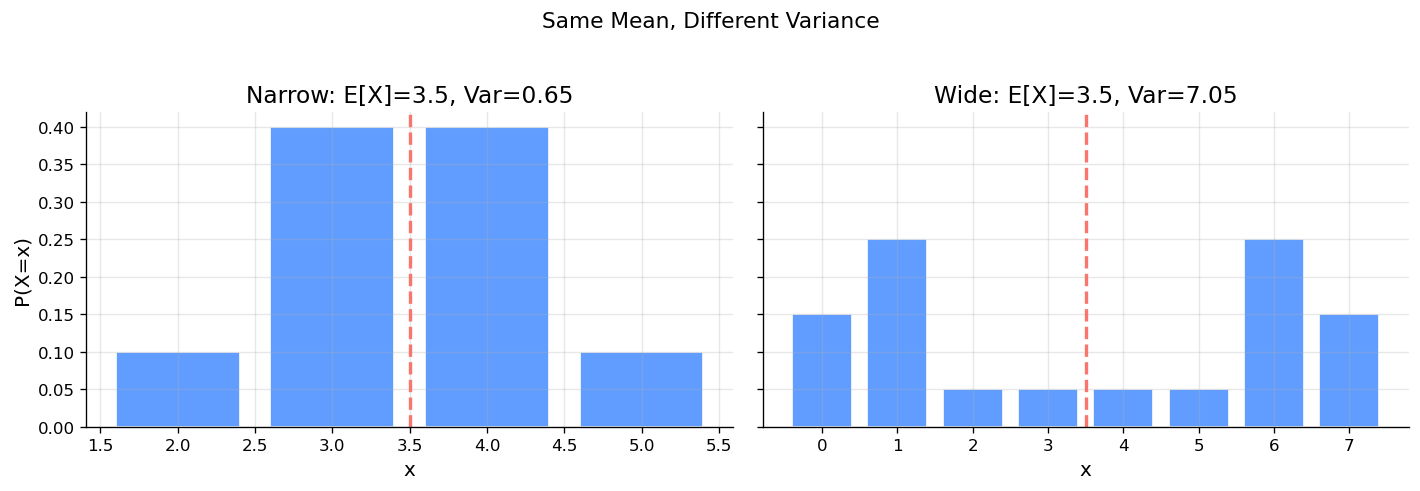

In [ ]:
# Two PMFs with the same mean (3.5) but different variance
pmf_narrow = {3: 0.4, 4: 0.4, 2: 0.1, 5: 0.1}  # concentrated near 3.5
pmf_wide = {
    1: 0.25,
    2: 0.05,
    3: 0.05,
    4: 0.05,
    5: 0.05,
    6: 0.25,
    0: 0.15,
    7: 0.15,
}  # spread out

mu_n = expected_value(pmf_narrow)
mu_w = expected_value(pmf_wide)
var_n = variance(pmf_narrow)
var_w = variance(pmf_wide)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(pmf_narrow.keys(), pmf_narrow.values(), color="#619CFF", edgecolor="white")
axes[0].axvline(mu_n, color="#F8766D", linewidth=2, linestyle="--")
axes[0].set_title(f"Narrow: E[X]={mu_n:.1f}, Var={var_n:.2f}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("P(X=x)")

axes[1].bar(pmf_wide.keys(), pmf_wide.values(), color="#619CFF", edgecolor="white")
axes[1].axvline(mu_w, color="#F8766D", linewidth=2, linestyle="--")
axes[1].set_title(f"Wide: E[X]={mu_w:.1f}, Var={var_w:.2f}")
axes[1].set_xlabel("x")

plt.suptitle("Same Mean, Different Variance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 7. Connecting Back: Total Expectation Revisited

In notebook 04 we previewed the **law of total expectation**. Now we can state it formally:

> **Theorem 5.8 (Law of total expectation).** If $\{A_1, \dots, A_n\}$ is a partition of $\Omega$:
>
> $$E[X] = \sum_{i=1}^n E[X \mid A_i] \, P(A_i)$$

This is the expectation analogue of the law of total probability. The overall mean is a weighted average of the conditional means within each group.

Similarly, there is a **law of total variance** (sometimes called the *variance decomposition*):

$$\text{Var}(X) = E[\text{Var}(X|A)] + \text{Var}(E[X|A])$$

"The total variance = average within-group variance + between-group variance." This is the foundation of ANOVA (Module 06) and hierarchical models (Module 09).

---

## 8. Looking Ahead: Named Distributions

Everything in this notebook applies to **any** discrete random variable. In Module 02, we'll study specific **families** of distributions — PMFs that arise so frequently in practice that they have names, formulas, and well-known properties:

| Distribution  | What it models                    | PMF                                     |
|---------------|-----------------------------------|-----------------------------------------|
| **Bernoulli** | Single yes/no trial               | $P(X=1) = p$, $P(X=0) = 1-p$            |
| **Binomial**  | Number of successes in $n$ trials | $P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$ |
| **Poisson**   | Count of rare events              | $P(X=k) = e^{-\lambda} \lambda^k / k!$  |
| **Geometric** | Trials until first success        | $P(X=k) = (1-p)^{k-1} p$                |

For each, we'll derive the PMF from first principles, compute $E[X]$ and $\text{Var}(X)$ using the tools from this notebook, implement them from scratch, then introduce `scipy.stats`.

---

## Exercises

**Exercise 5.1 (PMF).** Let $X$ be the absolute difference of two fair dice: $X = |D_1 - D_2|$. Compute the PMF of $X$ by enumeration. Plot it. What is $P(X = 0)$?

**Exercise 5.2 (CDF).** Using the PMF from Exercise 5.1, compute the CDF. What is $P(X \leq 2)$?

**Exercise 5.3 (Expected value).** A game costs \$5 to play. You roll a die: if you roll 6 you win \$20, otherwise you win nothing. Let $X$ be your net profit. Compute $E[X]$. Is the game fair?

**Exercise 5.4 (Variance by hand).** Compute $\text{Var}(X)$ for a coin flip where $X = 1$ (heads) with probability $p$ and $X = 0$ (tails) with probability $1-p$. Show that $\text{Var}(X) = p(1-p)$. At what value of $p$ is the variance maximised?

**Exercise 5.5 (Linearity).** You roll 5 fair dice. Without computing the full PMF of the sum, use linearity of expectation to find $E[\text{sum}]$ and (using independence) $\text{Var}(\text{sum})$.

**Exercise 5.6 (Simulation).** Generate 100,000 samples of $X$ = "number of heads in 10 fair coin flips". Plot the PMF (normalised histogram). Compute the sample mean and variance. Compare to the theoretical values $E[X] = np = 5$ and $\text{Var}(X) = np(1-p) = 2.5$. (*You're discovering the Binomial distribution — Module 02!*)

**Exercise 5.7 (Challenge — St. Petersburg paradox).** A casino offers a game: flip a coin until you get tails. If tails appears on flip $k$, you win $2^k$ dollars. Compute $E[X]$ (the expected winnings). What does this tell you about the limitations of expected value as a decision-making tool?

---

## Key Takeaways

1. A **random variable** $X : \Omega \to \mathbb{R}$ maps outcomes to numbers — the bridge from events to statistics.
2. The **PMF** $p_X(x) = P(X=x)$ fully describes a discrete RV. The **CDF** $F(x) = P(X \leq x)$ accumulates it.
3. **Expected value** $E[X] = \sum x \cdot p_X(x)$ is the probability-weighted average — the balance point of the distribution.
4. **Linearity of expectation** ($E[X+Y] = E[X] + E[Y]$, always) is one of the most powerful tools in probability.
5. **Variance** $\text{Var}(X) = E[(X-\mu)^2]$ measures spread. Scaling by $a$ multiplies variance by $a^2$.
6. These tools are all we need to analyse the **named distributions** in Module 02.

**Next:** [06_inequalities.ipynb](06_inequalities.ipynb) — Markov and Chebyshev inequalities, and the proof of the law of large numbers.

In [13]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-05-35.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-10-14.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@13-42-51.gif
  ✓ media/gifs/ConditionalProbVenn@2026-03-19@13-48-05.gif
  ✓ media/gifs/DiceHistogram@2026-03-19@13-43-26.gif
  ✓ media/gifs/ExpectedValueBalance@2026-03-19@14-01-49.gif
  ✓ media/gifs/PascalTriangle@2026-03-19@13-44-25.gif
  ✓ media/gifs/TotalProbabilityPartition@2026-03-19@13-50-32.gif
  ✓ media/gifs/TreeDiagram@2026-03-19@13-44-07.gif
  ✓ media/gifs/ExpectedValueBalance_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
